In [1]:
import os
import json
import time
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import pennylane as qml
import torch
import torch.nn as nn

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix
)

In [2]:
RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

torch.set_default_dtype(torch.float32)

print("PennyLane:", qml.__version__)
print("PyTorch:", torch.__version__)

PennyLane: 0.45.1
PyTorch: 2.13.0+cpu


In [3]:
data_file = "quantum_encoded_healthcare_data.xlsx"

model_file = (
    "optimized_variational_quantum_model.pt"
)

results_file = (
    "quantum_noise_simulation_results.xlsx"
)

configuration_file = (
    "quantum_noise_simulation_config.json"
)

for required_file in [data_file, model_file]:
    if not os.path.exists(required_file):
        raise FileNotFoundError(
            f"{required_file} was not found. "
            "Run Quantum Circuit Optimization first."
        )

print("Required files found.")

Required files found.


In [4]:
X_test_df = pd.read_excel(
    data_file,
    sheet_name="X_Test_Quantum"
)

y_test_df = pd.read_excel(
    data_file,
    sheet_name="Y_Test"
)

class_mapping = pd.read_excel(
    data_file,
    sheet_name="Class_Mapping"
)

X_test = X_test_df.to_numpy(
    dtype=np.float32
)

y_test = y_test_df[
    "encoded_target"
].to_numpy(dtype=np.int64)

print("Test features:", X_test.shape)
print("Test target:", y_test.shape)

Test features: (100, 4)
Test target: (100,)


In [5]:
try:
    checkpoint = torch.load(
        model_file,
        map_location="cpu",
        weights_only=False
    )
except TypeError:
    checkpoint = torch.load(
        model_file,
        map_location="cpu"
    )

print("Checkpoint fields:")
print(checkpoint.keys())

selected_circuit = checkpoint["circuit_name"]
selected_template = checkpoint["template"]
selected_layers = int(checkpoint["layers"])
n_qubits = int(checkpoint["n_qubits"])
n_classes = int(checkpoint["n_classes"])
weight_shapes = checkpoint["weight_shapes"]

print("Selected circuit:", selected_circuit)
print("Template:", selected_template)
print("Layers:", selected_layers)
print("Qubits:", n_qubits)
print("Classes:", n_classes)
print("Weight shapes:", weight_shapes)

Checkpoint fields:
dict_keys(['model_state_dict', 'circuit_name', 'template', 'layers', 'training_epochs', 'n_qubits', 'n_classes', 'weight_shapes', 'class_mapping', 'random_state'])
Selected circuit: Basic_2_Layers
Template: basic
Layers: 2
Qubits: 4
Classes: 12
Weight shapes: {'weights': (2, 4)}


In [6]:
assert X_test.shape[1] == n_qubits

assert len(np.unique(y_test)) <= n_classes

assert selected_template in [
    "basic",
    "strong"
]

print("Dataset and model are compatible.")

Dataset and model are compatible.


In [7]:
noise_models = [
    "none",
    "depolarizing",
    "amplitude_damping",
    "phase_damping"
]

noise_probabilities = [
    0.000,
    0.001,
    0.005,
    0.010,
    0.020,
    0.050
]

print("Noise models:", noise_models)
print("Noise probabilities:", noise_probabilities)

Noise models: ['none', 'depolarizing', 'amplitude_damping', 'phase_damping']
Noise probabilities: [0.0, 0.001, 0.005, 0.01, 0.02, 0.05]


In [8]:
def apply_noise_channel(
    noise_model,
    probability,
    wire
):
    if probability <= 0 or noise_model == "none":
        return

    if noise_model == "depolarizing":
        qml.DepolarizingChannel(
            probability,
            wires=wire
        )

    elif noise_model == "amplitude_damping":
        qml.AmplitudeDamping(
            probability,
            wires=wire
        )

    elif noise_model == "phase_damping":
        qml.PhaseDamping(
            probability,
            wires=wire
        )

    else:
        raise ValueError(
            f"Unknown noise model: {noise_model}"
        )

In [9]:
def apply_variational_layer(
    weights,
    layer_index,
    template_name,
    wires
):
    if template_name == "basic":
        for wire in wires:
            qml.RY(
                weights[layer_index, wire],
                wires=wire
            )

        if len(wires) == 2:
            qml.CNOT(
                wires=[wires[0], wires[1]]
            )
        else:
            for wire_index in range(len(wires)):
                control_wire = wires[wire_index]

                target_wire = wires[
                    (wire_index + 1) % len(wires)
                ]

                qml.CNOT(
                    wires=[
                        control_wire,
                        target_wire
                    ]
                )

    elif template_name == "strong":
        for wire in wires:
            qml.Rot(
                weights[layer_index, wire, 0],
                weights[layer_index, wire, 1],
                weights[layer_index, wire, 2],
                wires=wire
            )

        entanglement_range = (
            layer_index % (len(wires) - 1)
        ) + 1

        for wire_index in range(len(wires)):
            control_wire = wires[wire_index]

            target_wire = wires[
                (
                    wire_index
                    + entanglement_range
                )
                % len(wires)
            ]

            qml.CNOT(
                wires=[
                    control_wire,
                    target_wire
                ]
            )

    else:
        raise ValueError(
            f"Unknown template: {template_name}"
        )

In [10]:
def build_noisy_quantum_circuit(
    template_name,
    number_of_layers,
    noise_model,
    noise_probability
):
    mixed_device = qml.device(
        "default.mixed",
        wires=n_qubits
    )

    wires = list(range(n_qubits))

    @qml.qnode(
        mixed_device,
        interface="torch",
        diff_method="backprop"
    )
    def noisy_circuit(inputs, weights):
        qml.AngleEmbedding(
            features=inputs,
            wires=wires,
            rotation="Y"
        )
        for wire in wires:
            apply_noise_channel(
                noise_model,
                noise_probability,
                wire
            )
        for layer_index in range(
            number_of_layers
        ):
            apply_variational_layer(
                weights,
                layer_index,
                template_name,
                wires
            )

            for wire in wires:
                apply_noise_channel(
                    noise_model,
                    noise_probability,
                    wire
                )

        return [
            qml.expval(qml.PauliZ(wire))
            for wire in wires
        ]

    return noisy_circuit

In [11]:
class NoisyQuantumClassifier(nn.Module):
    def __init__(
        self,
        quantum_circuit,
        weight_shapes,
        number_of_classes
    ):
        super().__init__()

        self.quantum_layer = qml.qnn.TorchLayer(
            quantum_circuit,
            weight_shapes
        )

        self.output_layer = nn.Linear(
            n_qubits,
            number_of_classes
        )

    def forward(self, inputs):
        quantum_features = self.quantum_layer(
            inputs
        )

        return self.output_layer(
            quantum_features
        )

In [12]:
noiseless_circuit = build_noisy_quantum_circuit(
    template_name=selected_template,
    number_of_layers=selected_layers,
    noise_model="none",
    noise_probability=0.0
)

noiseless_model = NoisyQuantumClassifier(
    quantum_circuit=noiseless_circuit,
    weight_shapes=weight_shapes,
    number_of_classes=n_classes
)

noiseless_model.load_state_dict(
    checkpoint["model_state_dict"]
)

noiseless_model.eval()

X_test_tensor = torch.tensor(
    X_test,
    dtype=torch.float32
)

with torch.no_grad():
    noiseless_logits = noiseless_model(
        X_test_tensor
    )

    noiseless_probabilities = torch.softmax(
        noiseless_logits,
        dim=1
    ).cpu().numpy()

print(
    "Noiseless probability shape:",
    noiseless_probabilities.shape
)

assert noiseless_probabilities.shape == (
    len(X_test),
    n_classes
)

print("Noiseless circuit reconstruction succeeded.")

Noiseless probability shape: (100, 12)
Noiseless circuit reconstruction succeeded.


In [13]:
def evaluate_probabilities(
    targets,
    probabilities
):
    predictions = np.argmax(
        probabilities,
        axis=1
    )

    accuracy = accuracy_score(
        targets,
        predictions
    )

    balanced_accuracy = balanced_accuracy_score(
        targets,
        predictions
    )

    precision, recall, macro_f1, _ = (
        precision_recall_fscore_support(
            targets,
            predictions,
            average="macro",
            zero_division=0
        )
    )

    _, _, weighted_f1, _ = (
        precision_recall_fscore_support(
            targets,
            predictions,
            average="weighted",
            zero_division=0
        )
    )

    top_3_classes = np.argsort(
        probabilities,
        axis=1
    )[:, -3:]

    top_3_accuracy = np.mean([
        target in classes
        for target, classes
        in zip(targets, top_3_classes)
    ])

    mean_confidence = np.max(
        probabilities,
        axis=1
    ).mean()

    return {
        "accuracy": accuracy,
        "balanced_accuracy": balanced_accuracy,
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "top_3_accuracy": top_3_accuracy,
        "mean_confidence": mean_confidence
    }, predictions

In [14]:
def simulate_noise_configuration(
    noise_model,
    noise_probability
):
    noisy_circuit = build_noisy_quantum_circuit(
        template_name=selected_template,
        number_of_layers=selected_layers,
        noise_model=noise_model,
        noise_probability=noise_probability
    )

    noisy_model = NoisyQuantumClassifier(
        quantum_circuit=noisy_circuit,
        weight_shapes=weight_shapes,
        number_of_classes=n_classes
    )

    noisy_model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    noisy_model.eval()

    start_time = time.time()

    with torch.no_grad():
        logits = noisy_model(X_test_tensor)

        probabilities = torch.softmax(
            logits,
            dim=1
        ).cpu().numpy()

    simulation_seconds = (
        time.time() - start_time
    )

    metrics, predictions = (
        evaluate_probabilities(
            y_test,
            probabilities
        )
    )

    return {
        "probabilities": probabilities,
        "predictions": predictions,
        "metrics": metrics,
        "simulation_seconds": simulation_seconds
    }

In [15]:
simulation_results = {}
noise_metric_rows = []

simulation_settings = [
    ("none", 0.0)
]

for noise_model in [
    "depolarizing",
    "amplitude_damping",
    "phase_damping"
]:
    for probability in noise_probabilities[1:]:
        simulation_settings.append(
            (noise_model, probability)
        )

print(
    "Total simulations:",
    len(simulation_settings)
)

for noise_model, probability in simulation_settings:
    simulation_name = (
        f"{noise_model}_{probability:.3f}"
    )

    print("Running:", simulation_name)

    result = simulate_noise_configuration(
        noise_model,
        probability
    )

    simulation_results[simulation_name] = result

    row = {
        "simulation": simulation_name,
        "noise_model": noise_model,
        "noise_probability": probability,
        "simulation_seconds":
            result["simulation_seconds"]
    }

    row.update(result["metrics"])
    noise_metric_rows.append(row)

noise_metrics = pd.DataFrame(
    noise_metric_rows
)

display(noise_metrics)

Total simulations: 16
Running: none_0.000
Running: depolarizing_0.001
Running: depolarizing_0.005
Running: depolarizing_0.010
Running: depolarizing_0.020
Running: depolarizing_0.050
Running: amplitude_damping_0.001
Running: amplitude_damping_0.005
Running: amplitude_damping_0.010
Running: amplitude_damping_0.020
Running: amplitude_damping_0.050
Running: phase_damping_0.001
Running: phase_damping_0.005
Running: phase_damping_0.010
Running: phase_damping_0.020
Running: phase_damping_0.050


,simulation,noise_model,noise_probability,simulation_seconds,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,top_3_accuracy,mean_confidence
0,none_0.000,none,0.000,0.202619,0.27,0.250331,0.243782,0.250331,0.197958,0.207900,0.63,0.274564
1,depolarizing_0.001,depolarizing,0.001,0.111486,0.27,0.250331,0.243782,0.250331,0.197958,0.207900,0.63,0.273668
2,depolarizing_0.005,depolarizing,0.005,0.111013,0.26,0.239914,0.234358,0.239914,0.187420,0.197603,0.64,0.270083
3,depolarizing_0.010,depolarizing,0.010,0.104228,0.26,0.239914,0.234358,0.239914,0.187420,0.197603,0.64,0.265610
4,depolarizing_0.020,depolarizing,0.020,0.098110,0.26,0.239914,0.235579,0.239914,0.186733,0.197125,0.65,0.256751
5,depolarizing_0.050,depolarizing,0.050,0.092130,0.24,0.218750,0.139216,0.218750,0.155375,0.168511,0.66,0.230541
6,amplitude_damping_0.001,amplitude_damping,0.001,0.123767,0.27,0.250331,0.243782,0.250331,0.197958,0.207900,0.63,0.274093
7,amplitude_damping_0.005,amplitude_damping,0.005,0.099997,0.27,0.250331,0.241821,0.250331,0.198032,0.207805,0.63,0.272214
8,amplitude_damping_0.010,amplitude_damping,0.010,0.198937,0.27,0.250331,0.201074,0.250331,0.196551,0.206660,0.63,0.269874
9,amplitude_damping_0.020,amplitude_damping,0.020,0.211513,0.27,0.250331,0.201074,0.250331,0.196551,0.206660,0.64,0.265188


In [16]:
baseline_row = noise_metrics[
    noise_metrics["noise_model"] == "none"
].iloc[0]

noise_metrics["accuracy_change"] = (
    noise_metrics["accuracy"]
    - baseline_row["accuracy"]
)

noise_metrics["macro_f1_change"] = (
    noise_metrics["macro_f1"]
    - baseline_row["macro_f1"]
)

noise_metrics["top_3_accuracy_change"] = (
    noise_metrics["top_3_accuracy"]
    - baseline_row["top_3_accuracy"]
)

noise_metrics["confidence_change"] = (
    noise_metrics["mean_confidence"]
    - baseline_row["mean_confidence"]
)

display(noise_metrics)

,simulation,noise_model,noise_probability,simulation_seconds,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,top_3_accuracy,mean_confidence,accuracy_change,macro_f1_change,top_3_accuracy_change,confidence_change
0,none_0.000,none,0.000,0.202619,0.27,0.250331,0.243782,0.250331,0.197958,0.207900,0.63,0.274564,0.00,0.000000,0.00,0.000000
1,depolarizing_0.001,depolarizing,0.001,0.111486,0.27,0.250331,0.243782,0.250331,0.197958,0.207900,0.63,0.273668,0.00,0.000000,0.00,-0.000896
2,depolarizing_0.005,depolarizing,0.005,0.111013,0.26,0.239914,0.234358,0.239914,0.187420,0.197603,0.64,0.270083,-0.01,-0.010537,0.01,-0.004481
3,depolarizing_0.010,depolarizing,0.010,0.104228,0.26,0.239914,0.234358,0.239914,0.187420,0.197603,0.64,0.265610,-0.01,-0.010537,0.01,-0.008954
4,depolarizing_0.020,depolarizing,0.020,0.098110,0.26,0.239914,0.235579,0.239914,0.186733,0.197125,0.65,0.256751,-0.01,-0.011224,0.02,-0.017813
5,depolarizing_0.050,depolarizing,0.050,0.092130,0.24,0.218750,0.139216,0.218750,0.155375,0.168511,0.66,0.230541,-0.03,-0.042583,0.03,-0.044023
6,amplitude_damping_0.001,amplitude_damping,0.001,0.123767,0.27,0.250331,0.243782,0.250331,0.197958,0.207900,0.63,0.274093,0.00,0.000000,0.00,-0.000472
7,amplitude_damping_0.005,amplitude_damping,0.005,0.099997,0.27,0.250331,0.241821,0.250331,0.198032,0.207805,0.63,0.272214,0.00,0.000075,0.00,-0.002350
8,amplitude_damping_0.010,amplitude_damping,0.010,0.198937,0.27,0.250331,0.201074,0.250331,0.196551,0.206660,0.63,0.269874,0.00,-0.001407,0.00,-0.004690
9,amplitude_damping_0.020,amplitude_damping,0.020,0.211513,0.27,0.250331,0.201074,0.250331,0.196551,0.206660,0.64,0.265188,0.00,-0.001407,0.01,-0.009376


In [17]:
baseline_predictions = simulation_results[
    "none_0.000"
]["predictions"]

stability_values = []

for _, row in noise_metrics.iterrows():
    simulation_name = row["simulation"]

    noisy_predictions = simulation_results[
        simulation_name
    ]["predictions"]

    stability = np.mean(
        noisy_predictions
        == baseline_predictions
    )

    stability_values.append(stability)

noise_metrics[
    "prediction_stability"
] = stability_values

display(
    noise_metrics[
        [
            "simulation",
            "accuracy",
            "macro_f1",
            "prediction_stability"
        ]
    ]
)

,simulation,accuracy,macro_f1,prediction_stability
0,none_0.000,0.27,0.197958,1.00
1,depolarizing_0.001,0.27,0.197958,1.00
2,depolarizing_0.005,0.26,0.187420,0.99
3,depolarizing_0.010,0.26,0.187420,0.99
4,depolarizing_0.020,0.26,0.186733,0.97
5,depolarizing_0.050,0.24,0.155375,0.94
6,amplitude_damping_0.001,0.27,0.197958,1.00
7,amplitude_damping_0.005,0.27,0.198032,0.99
8,amplitude_damping_0.010,0.27,0.196551,0.98
9,amplitude_damping_0.020,0.27,0.196551,0.98


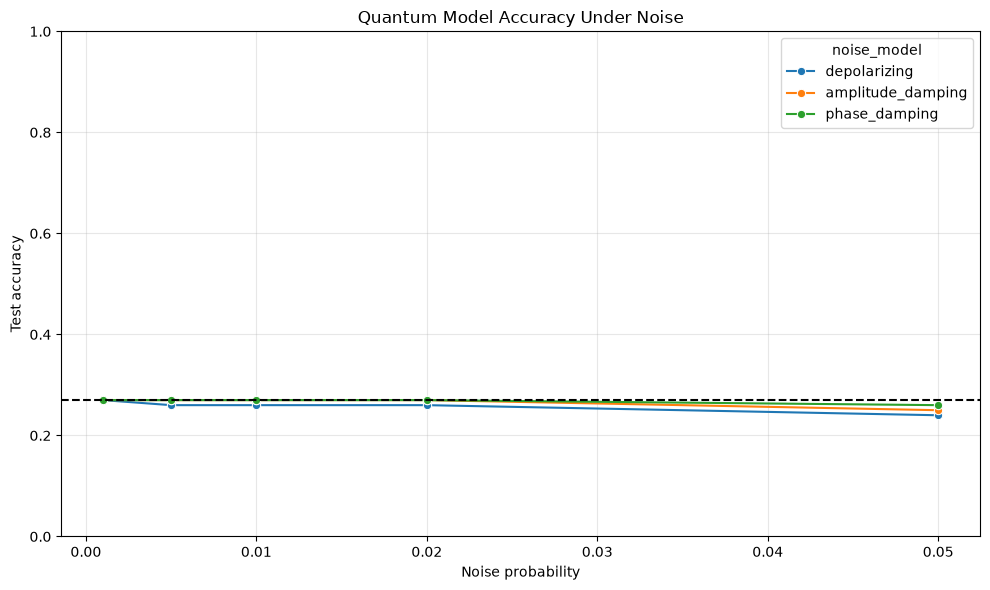

In [18]:
plot_data = noise_metrics[
    noise_metrics["noise_model"] != "none"
].copy()

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=plot_data,
    x="noise_probability",
    y="accuracy",
    hue="noise_model",
    marker="o"
)

plt.axhline(
    baseline_row["accuracy"],
    color="black",
    linestyle="--",
    label="Noiseless baseline"
)

plt.title("Quantum Model Accuracy Under Noise")
plt.xlabel("Noise probability")
plt.ylabel("Test accuracy")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

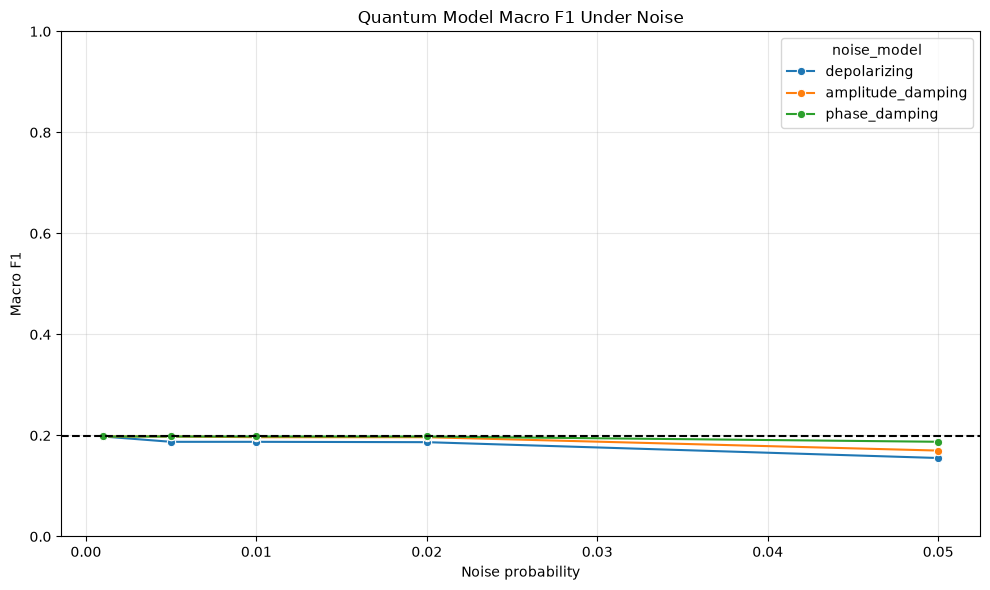

In [19]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=plot_data,
    x="noise_probability",
    y="macro_f1",
    hue="noise_model",
    marker="o"
)

plt.axhline(
    baseline_row["macro_f1"],
    color="black",
    linestyle="--",
    label="Noiseless baseline"
)

plt.title("Quantum Model Macro F1 Under Noise")
plt.xlabel("Noise probability")
plt.ylabel("Macro F1")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

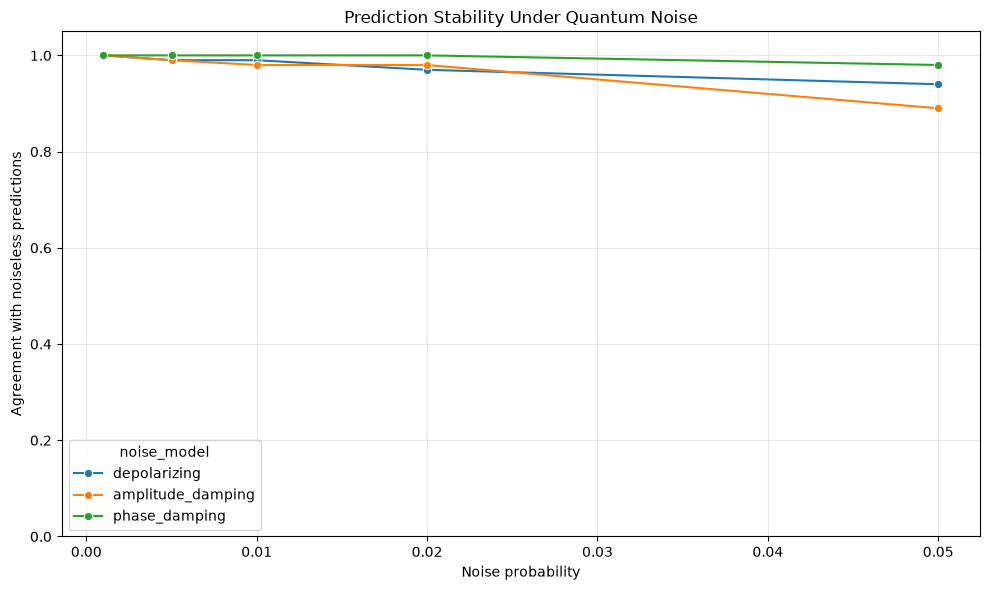

In [20]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=plot_data,
    x="noise_probability",
    y="prediction_stability",
    hue="noise_model",
    marker="o"
)

plt.title("Prediction Stability Under Quantum Noise")
plt.xlabel("Noise probability")
plt.ylabel("Agreement with noiseless predictions")
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [21]:
noisy_only = noise_metrics[
    noise_metrics["noise_model"] != "none"
].copy()

best_noisy_result = (
    noisy_only
    .sort_values(
        [
            "macro_f1",
            "prediction_stability"
        ],
        ascending=False
    )
    .iloc[0]
)

worst_noisy_result = (
    noisy_only
    .sort_values(
        [
            "macro_f1",
            "prediction_stability"
        ],
        ascending=True
    )
    .iloc[0]
)

print("Best noisy configuration:")
display(best_noisy_result.to_frame().T)

print("\nWorst noisy configuration:")
display(worst_noisy_result.to_frame().T)

Best noisy configuration:


,simulation,noise_model,noise_probability,simulation_seconds,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,top_3_accuracy,mean_confidence,accuracy_change,macro_f1_change,top_3_accuracy_change,confidence_change,prediction_stability
7,amplitude_damping_0.005,amplitude_damping,0.005,0.099997,0.27,0.250331,0.241821,0.250331,0.198032,0.207805,0.63,0.272214,0.0,0.000075,0.0,-0.00235,0.99



Worst noisy configuration:


,simulation,noise_model,noise_probability,simulation_seconds,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,top_3_accuracy,mean_confidence,accuracy_change,macro_f1_change,top_3_accuracy_change,confidence_change,prediction_stability
5,depolarizing_0.050,depolarizing,0.05,0.09213,0.24,0.21875,0.139216,0.21875,0.155375,0.168511,0.66,0.230541,-0.03,-0.042583,0.03,-0.044023,0.94


In [22]:
prediction_comparison = pd.DataFrame({
    "test_record": np.arange(
        1,
        len(y_test) + 1
    ),
    "actual_encoded_target": y_test,
    "noiseless_prediction":
        baseline_predictions,
    "noiseless_confidence": np.max(
        simulation_results[
            "none_0.000"
        ]["probabilities"],
        axis=1
    )
})

for _, row in noise_metrics.iterrows():
    simulation_name = row["simulation"]

    if simulation_name == "none_0.000":
        continue

    safe_column_name = (
        simulation_name
        .replace(".", "_")
    )

    result = simulation_results[
        simulation_name
    ]

    prediction_comparison[
        f"{safe_column_name}_prediction"
    ] = result["predictions"]

    prediction_comparison[
        f"{safe_column_name}_changed"
    ] = (
        result["predictions"]
        != baseline_predictions
    )

display(prediction_comparison.head())

,test_record,actual_encoded_target,noiseless_prediction,noiseless_confidence,depolarizing_0_001_prediction,depolarizing_0_001_changed,depolarizing_0_005_prediction,depolarizing_0_005_changed,depolarizing_0_010_prediction,depolarizing_0_010_changed,...,phase_damping_0_001_prediction,phase_damping_0_001_changed,phase_damping_0_005_prediction,phase_damping_0_005_changed,phase_damping_0_010_prediction,phase_damping_0_010_changed,phase_damping_0_020_prediction,phase_damping_0_020_changed,phase_damping_0_050_prediction,phase_damping_0_050_changed
0,1,9,4,0.216870,4,False,4,False,4,False,...,4,False,4,False,4,False,4,False,4,False
1,2,2,2,0.531624,2,False,2,False,2,False,...,2,False,2,False,2,False,2,False,2,False
2,3,10,10,0.253485,10,False,10,False,10,False,...,10,False,10,False,10,False,10,False,10,False
3,4,10,2,0.155397,2,False,2,False,2,False,...,2,False,2,False,2,False,2,False,2,False
4,5,5,4,0.246902,4,False,4,False,4,False,...,4,False,4,False,4,False,4,False,4,False


In [23]:
robustness_summary = (
    noise_metrics[
        noise_metrics["noise_model"] != "none"
    ]
    .groupby("noise_model")
    .agg(
        mean_accuracy=("accuracy", "mean"),
        minimum_accuracy=("accuracy", "min"),
        mean_macro_f1=("macro_f1", "mean"),
        minimum_macro_f1=("macro_f1", "min"),
        mean_prediction_stability=(
            "prediction_stability",
            "mean"
        ),
        minimum_prediction_stability=(
            "prediction_stability",
            "min"
        )
    )
    .reset_index()
)

display(robustness_summary)

,noise_model,mean_accuracy,minimum_accuracy,mean_macro_f1,minimum_macro_f1,mean_prediction_stability,minimum_prediction_stability
0,amplitude_damping,0.266,0.25,0.191836,0.170086,0.968,0.89
1,depolarizing,0.258,0.24,0.182981,0.155375,0.978,0.94
2,phase_damping,0.268,0.26,0.195866,0.187502,0.996,0.98


In [24]:
assert len(noise_metrics) == 16

assert noise_metrics[
    "noise_probability"
].between(0, 1).all()

assert noise_metrics[
    "accuracy"
].between(0, 1).all()

assert noise_metrics[
    "macro_f1"
].between(0, 1).all()

assert noise_metrics[
    "prediction_stability"
].between(0, 1).all()

for simulation_name, result in (
    simulation_results.items()
):
    probability_sums = result[
        "probabilities"
    ].sum(axis=1)

    assert np.allclose(
        probability_sums,
        1.0,
        atol=1e-5
    ), (
        f"Invalid probabilities in "
        f"{simulation_name}"
    )

print("All quantum noise checks passed.")

All quantum noise checks passed.


In [25]:
configuration = {
    "stage": "Quantum Noise Simulation",
    "input_model": model_file,
    "selected_circuit": selected_circuit,
    "selected_template": selected_template,
    "selected_layers": selected_layers,
    "simulator": "default.mixed",
    "noise_models": [
        "depolarizing",
        "amplitude_damping",
        "phase_damping"
    ],
    "noise_probabilities": (
        noise_probabilities
    ),
    "simulation_type": (
        "Analytic density-matrix simulation"
    ),
    "baseline_accuracy": float(
        baseline_row["accuracy"]
    ),
    "baseline_macro_f1": float(
        baseline_row["macro_f1"]
    )
}

with open(configuration_file, "w") as file:
    json.dump(
        configuration,
        file,
        indent=4
    )

with pd.ExcelWriter(
    results_file,
    engine="openpyxl"
) as writer:

    noise_metrics.to_excel(
        writer,
        sheet_name="Noise_Metrics",
        index=False
    )

    robustness_summary.to_excel(
        writer,
        sheet_name="Robustness_Summary",
        index=False
    )

    prediction_comparison.to_excel(
        writer,
        sheet_name="Prediction_Comparison",
        index=False
    )

    pd.DataFrame(
        [best_noisy_result]
    ).to_excel(
        writer,
        sheet_name="Best_Noisy_Result",
        index=False
    )

    pd.DataFrame(
        [worst_noisy_result]
    ).to_excel(
        writer,
        sheet_name="Worst_Noisy_Result",
        index=False
    )

    pd.DataFrame(
        list(configuration.items()),
        columns=["configuration", "value"]
    ).to_excel(
        writer,
        sheet_name="Configuration",
        index=False
    )

print("Saved results:", results_file)
print("Saved configuration:", configuration_file)

Saved results: quantum_noise_simulation_results.xlsx
Saved configuration: quantum_noise_simulation_config.json


In [26]:
for file_name in [
    results_file,
    configuration_file
]:
    print(
        file_name,
        "exists:",
        os.path.exists(file_name)
    )

print("\nNoiseless accuracy:",
      round(baseline_row["accuracy"], 4))

print("Noiseless macro F1:",
      round(baseline_row["macro_f1"], 4))

print("\nBest noisy simulation:",
      best_noisy_result["simulation"])

print("Best noisy macro F1:",
      round(best_noisy_result["macro_f1"], 4))

print("\nWorst noisy simulation:",
      worst_noisy_result["simulation"])

print("Worst noisy macro F1:",
      round(worst_noisy_result["macro_f1"], 4))

quantum_noise_simulation_results.xlsx exists: True
quantum_noise_simulation_config.json exists: True

Noiseless accuracy: 0.27
Noiseless macro F1: 0.198

Best noisy simulation: amplitude_damping_0.005
Best noisy macro F1: 0.198

Worst noisy simulation: depolarizing_0.050
Worst noisy macro F1: 0.1554
